# Vaccination Data Analysis and Visualization


##### **Project Type** - Exploratory Data Analysis (EDA)
##### **Contribution** - Individual
##### **Team Member** - Nagarjun Maharana


# **Project Summary -**

# Project Summary

This project analyzes five supplied country-level datasets: vaccination coverage, disease incidence, reported disease cases, vaccine introduction, and vaccine schedules. Its objective is to identify measurable trends and country/region differences that can support public-health prioritization and planning.

The preparation standardizes column names, country identifiers, years, and numeric measures; removes exact duplicate rows; and preserves missing values rather than replacing them with zero. Coverage has parallel administrative and official reporting categories. Core coverage comparisons use administrative observations to avoid treating those reporting categories as separate programs, while both categories remain available in the cleaned source table. The data have different grains, so country-year-only joins can multiply records when several antigens and diseases are present.

The notebook is organized into univariate, bivariate, and multivariate analysis and provides 20 chart sections with code, interpretation prompts, and business impact. Coverage/incidence associations use explicit candidate vaccine-antigen/disease pairs and are ecological, descriptive comparisons only. They do not establish vaccine effectiveness or causation; surveillance, denominators, access, population structure, reporting completeness, and timing can affect observed relationships.

The supplied files do not include gender, education, urban/rural residence, population density, socioeconomic groups, or monthly observations. Questions requiring those attributes cannot be answered from these data. A SQLite database, cleaned CSV exports, SQL starter queries, and a Power BI dashboard specification are included as supporting deliverables. The contributor is identified above. Run the notebook in order, verify the generated findings, and submit the supporting database, cleaned exports, documentation, and native `.pbix` report if required by the evaluator.


# GitHub Link


Not published. Add the repository URL if this project is uploaded to GitHub.


# **Problem Statement**


Analyze global vaccination coverage, vaccine introduction and schedules, reported disease cases, and incidence using country-year data. Identify trends and disparities that can inform public-health prioritization while documenting data quality, join assumptions, and the limits of aggregate observational data.


#### **Define Your Business Objective?**

Provide reproducible evidence to prioritize low reported country-antigen-year coverage, monitor vaccine introduction and schedule information, and investigate disease burden alongside coverage. The analysis is intended for screening and planning; it does not estimate causal vaccine effectiveness.


# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 20 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [3]:
from pathlib import Path
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns, warnings
import zipfile # Import zipfile module

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns',80)

# Define the path to the zip file and the extraction directory
zip_file_path = Path('/content/Vaccination project-20260923T163429Z-1-001.zip')
if not zip_file_path.exists():
    zip_file_path = Path('/content/Vaccination project.zip')
extract_dir = Path('/content')

# Unzip the file if it exists and the target directory doesn't already contain the unzipped folder
if zip_file_path.exists():
    # Determine the name of the folder inside the zip based on typical structure
    # Assuming the zip contains a folder named 'Vaccination project'
    extracted_folder_name = 'Vaccination project'
    if not (extract_dir / extracted_folder_name).exists():
        with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
            zip_ref.extractall(extract_dir)
        print(f"'{zip_file_path.name}' unzipped to '{extract_dir}'")

# Update DATA_DIR to point to the correct location of the unzipped files
DATA_DIR = extract_dir / extracted_folder_name

FILES={'coverage':'coverage-data.xlsx','incidence':'incidence-rate-data.xlsx','cases':'reported-cases-data.xlsx','introduction':'vaccine-introduction-data.xlsx','schedule':'vaccine-schedule-data.xlsx'}
def load_clean(file):
    d=pd.read_excel(DATA_DIR/file)
    d.columns=d.columns.str.strip().str.lower().str.replace(r'[^a-z0-9]+','_',regex=True).str.strip('_')
    d=d.drop_duplicates().copy()
    for c in ['year','target_number','doses','coverage','incidence_rate','cases','schedule_rounds']:
        if c in d: d[c]=pd.to_numeric(d[c],errors='coerce')
    for c in ['code','iso_3_code']:
        if c in d: d[c]=d[c].astype('string').str.strip().str.upper()
    return d
tables={k:load_clean(v) for k,v in FILES.items()}
coverage=tables['coverage']; incidence=tables['incidence']; cases=tables['cases']; introduction=tables['introduction']; schedule=tables['schedule']
coverage_admin=coverage[coverage.coverage_category.astype('string').str.upper().str.contains('ADMIN',na=False)].copy()
coverage_admin=coverage_admin[coverage_admin.coverage.notna() & coverage_admin.year.notna()].copy()
incidence['disease_norm']=incidence.disease.astype('string').str.upper().str.replace(r'[^A-Z0-9]+','_',regex=True)
cases['disease_norm']=cases.disease.astype('string').str.upper().str.replace(r'[^A-Z0-9]+','_',regex=True)
print('Loaded rows/columns:',{k:v.shape for k,v in tables.items()})
print('Primary coverage category: ADMIN; usable rows:',len(coverage_admin))


Loaded rows/columns: {'coverage': (399859, 11), 'incidence': (84946, 9), 'cases': (84870, 8), 'introduction': (138321, 6), 'schedule': (8053, 12)}
Primary coverage category: ADMIN; usable rows: 72030


### Dataset Loading

In [4]:
for k,v in tables.items(): print(f'{k}: {v.shape[0]:,} rows x {v.shape[1]} columns')


coverage: 399,859 rows x 11 columns
incidence: 84,946 rows x 9 columns
cases: 84,870 rows x 8 columns
introduction: 138,321 rows x 6 columns
schedule: 8,053 rows x 12 columns


### Dataset First View

In [5]:
for k,v in tables.items():
    print('\n'+k.upper()); display(v.head(3))



COVERAGE


,group,code,name,year,antigen,antigen_description,coverage_category,coverage_category_description,target_number,doses,coverage
0,COUNTRIES,ABW,Aruba,2023.0,BCG,BCG,ADMIN,Administrative coverage,NaN,NaN,NaN
1,COUNTRIES,ABW,Aruba,2023.0,BCG,BCG,OFFICIAL,Official coverage,NaN,NaN,NaN
2,COUNTRIES,ABW,Aruba,2023.0,DIPHCV4,"Diphtheria-containing vaccine, 4th dose (1st b...",ADMIN,Administrative coverage,1044.0,945.0,90.52



INCIDENCE


,group,code,name,year,disease,disease_description,denominator,incidence_rate,disease_norm
0,COUNTRIES,ABW,Aruba,2023.0,CRS,Congenital rubella syndrome,"per 10,000 live births",0.0,CRS
1,COUNTRIES,ABW,Aruba,2023.0,DIPHTHERIA,Diphtheria,"per 1,000,000 total population",0.0,DIPHTHERIA
2,COUNTRIES,ABW,Aruba,2023.0,INVASIVE_MENING,Invasive meningococcal disease,"per 1,000,000 total population",9.3,INVASIVE_MENING



CASES


,group,code,name,year,disease,disease_description,cases,disease_norm
0,COUNTRIES,ABW,Aruba,2023.0,CRS,Congenital rubella syndrome,0.0,CRS
1,COUNTRIES,ABW,Aruba,2023.0,DIPHTHERIA,Diphtheria,0.0,DIPHTHERIA
2,COUNTRIES,ABW,Aruba,2023.0,INVASIVE_MENING,Invasive meningococcal disease,1.0,INVASIVE_MENING



INTRODUCTION


,iso_3_code,countryname,who_region,year,description,intro
0,AFG,Afghanistan,EMRO,2023.0,aP (acellular pertussis) vaccine,No
1,AFG,Afghanistan,EMRO,2023.0,Hepatitis A vaccine,No
2,AFG,Afghanistan,EMRO,2023.0,Hepatitis B vaccine,Yes



SCHEDULE


,iso_3_code,countryname,who_region,year,vaccinecode,vaccine_description,schedulerounds,targetpop,targetpop_description,geoarea,ageadministered,sourcecomment
0,ABW,Aruba,AMRO,2023.0,DTAPHIBIPV,DTaP-Hib-IPV (acellular) vaccine,1.0,NaN,General/routine,NATIONAL,M2,NaN
1,ABW,Aruba,AMRO,2023.0,DTAPHIBIPV,DTaP-Hib-IPV (acellular) vaccine,2.0,NaN,General/routine,NATIONAL,M4,NaN
2,ABW,Aruba,AMRO,2023.0,DTAPHIBIPV,DTaP-Hib-IPV (acellular) vaccine,3.0,NaN,General/routine,NATIONAL,M6,NaN


### Dataset Rows & Columns count

In [6]:
pd.DataFrame([{'table':k,'rows':len(v),'columns':len(v.columns)} for k,v in tables.items()])


,table,rows,columns
0,coverage,399859,11
1,incidence,84946,9
2,cases,84870,8
3,introduction,138321,6
4,schedule,8053,12


### Dataset Information

In [7]:
for k,v in tables.items():
    print('\n'+k.upper()); v.info()



COVERAGE
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 399859 entries, 0 to 399858
Data columns (total 11 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   group                          399859 non-null  object 
 1   code                           399858 non-null  string 
 2   name                           398584 non-null  object 
 3   year                           399858 non-null  float64
 4   antigen                        399858 non-null  object 
 5   antigen_description            399858 non-null  object 
 6   coverage_category              399858 non-null  object 
 7   coverage_category_description  399858 non-null  object 
 8   target_number                  79030 non-null   float64
 9   doses                          79327 non-null   float64
 10  coverage                       230477 non-null  float64
dtypes: float64(4), object(6), string(1)
memory usage: 33.6+ MB

INCIDENCE
<class 'pan

#### Duplicate Values

In [8]:
pd.DataFrame([{'table':k,'exact_duplicate_rows_after_cleaning':int(v.duplicated().sum())} for k,v in tables.items()])


,table,exact_duplicate_rows_after_cleaning
0,coverage,0
1,incidence,0
2,cases,0
3,introduction,0
4,schedule,0


#### Missing Values/Null Values

In [9]:
pd.concat({k:v.isna().sum() for k,v in tables.items()},axis=1).fillna(0).astype(int)


,coverage,incidence,cases,introduction,schedule
group,0,0,0,0,0
code,1,1,1,0,0
name,1275,1,1,0,0
year,1,1,1,1,1
antigen,1,0,0,0,0
antigen_description,1,0,0,0,0
coverage_category,1,0,0,0,0
coverage_category_description,1,0,0,0,0
target_number,320829,0,0,0,0
doses,320532,0,0,0,0


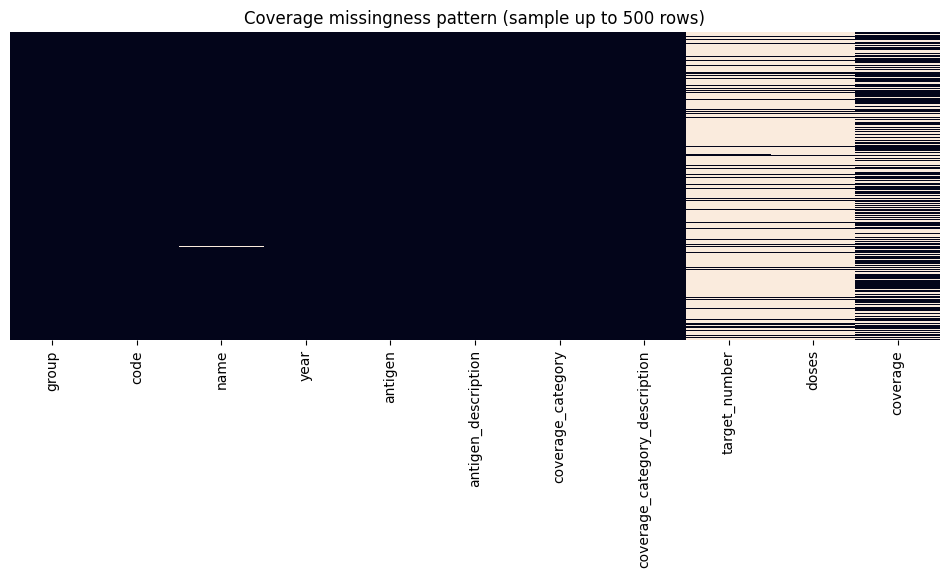

In [10]:
fig,ax=plt.subplots(figsize=(12,4)); sns.heatmap(coverage.isna().sample(min(500,len(coverage)),random_state=7),cbar=False,yticklabels=False,ax=ax); ax.set_title('Coverage missingness pattern (sample up to 500 rows)'); plt.show()


### What did you know about your dataset?

The tables have different grains: coverage is country × year × antigen × reporting category; incidence and reported cases are country × year × disease; introduction is country × year × vaccine; schedule rows describe vaccine round and target group. Administrative and official coverage are parallel reporting categories, so the core coverage series uses administrative records only. Missing is not zero. These are aggregated data, not individual vaccination histories.


## ***2. Understanding Your Variables***

In [11]:
{k:list(v.columns) for k,v in tables.items()}


{'coverage': ['group',
  'code',
  'name',
  'year',
  'antigen',
  'antigen_description',
  'coverage_category',
  'coverage_category_description',
  'target_number',
  'doses',
  'coverage'],
 'incidence': ['group',
  'code',
  'name',
  'year',
  'disease',
  'disease_description',
  'denominator',
  'incidence_rate',
  'disease_norm'],
 'cases': ['group',
  'code',
  'name',
  'year',
  'disease',
  'disease_description',
  'cases',
  'disease_norm'],
 'introduction': ['iso_3_code',
  'countryname',
  'who_region',
  'year',
  'description',
  'intro'],
 'schedule': ['iso_3_code',
  'countryname',
  'who_region',
  'year',
  'vaccinecode',
  'vaccine_description',
  'schedulerounds',
  'targetpop',
  'targetpop_description',
  'geoarea',
  'ageadministered',
  'sourcecomment']}

In [12]:
coverage_admin.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
group,72030,1,COUNTRIES,72030,NaN,NaN,NaN,NaN,NaN,NaN,NaN
code,72030,214,PAN,561,NaN,NaN,NaN,NaN,NaN,NaN,NaN
name,72030,214,Panama,561,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,72030.0,NaN,NaN,NaN,2009.548521,11.543292,1980.0,2002.0,2013.0,2019.0,2023.0
antigen,72030,60,DTPCV3,7585,NaN,NaN,NaN,NaN,NaN,NaN,NaN
antigen_description,72030,60,"DTP-containing vaccine, 3rd dose",7585,NaN,NaN,NaN,NaN,NaN,NaN,NaN
coverage_category,72030,1,ADMIN,72030,NaN,NaN,NaN,NaN,NaN,NaN,NaN
coverage_category_description,72030,1,Administrative coverage,72030,NaN,NaN,NaN,NaN,NaN,NaN,NaN
target_number,55040.0,NaN,NaN,NaN,390277768.31952,64889416714.102097,0.0,18652.0,135585.0,582830.0,11700000000000.0
doses,55090.0,NaN,NaN,NaN,595868.541809,2355044.614453,-222288203.0,14358.75,96176.0,445299.0,73953491.0


### Variables Description

Column definitions are provided in the assignment report. Country code/name and year identify geography and time; antigen or disease identifies the intervention/outcome; coverage, cases, incidence, introduction status, and schedule fields are the relevant measures. Check source-specific definitions and denominators before comparing rates across diseases.


### Check Unique Values for each variable.

In [13]:
for k,v in tables.items():
    print('\n',k); display(v.nunique(dropna=True).rename('unique_values').to_frame())



 coverage


,unique_values
group,9
code,245
name,242
year,44
antigen,69
antigen_description,69
coverage_category,5
coverage_category_description,5
target_number,24395
doses,53792



 incidence


,unique_values
group,4
code,221
name,221
year,44
disease,13
disease_description,13
denominator,5
incidence_rate,4977
disease_norm,13



 cases


,unique_values
group,4
code,221
name,221
year,44
disease,13
disease_description,13
cases,6634
disease_norm,13



 introduction


,unique_values
iso_3_code,195
countryname,194
who_region,6
year,84
description,21
intro,9



 schedule


,unique_values
iso_3_code,214
countryname,213
who_region,6
year,4
vaccinecode,86
vaccine_description,86
schedulerounds,7
targetpop,15
targetpop_description,10
geoarea,2


## 3. ***Data Wrangling***

### Data Wrangling Code

In [14]:
# Preserve nulls and parallel reporting categories. Inspect invalid values instead of clipping silently.
quality=pd.DataFrame([{'table':k,'rows':len(v),'columns':len(v.columns),'missing_cells':int(v.isna().sum().sum()),'exact_duplicates':int(v.duplicated().sum())} for k,v in tables.items()])
display(quality)
display(coverage_admin.loc[(coverage_admin.coverage<0)|(coverage_admin.coverage>100),['code','name','year','antigen','coverage']].head(20))


,table,rows,columns,missing_cells,exact_duplicates
0,coverage,399859,11,812024,0
1,incidence,84946,9,23369,0
2,cases,84870,8,19406,0
3,introduction,138321,6,5,0
4,schedule,8053,12,8256,0


,code,name,year,antigen,coverage
1247,AFG,Afghanistan,2015.0,DTPCV1,111.00
1275,AFG,Afghanistan,2015.0,PCV1,113.00
1307,AFG,Afghanistan,2014.0,BCG,101.16
1310,AFG,Afghanistan,2014.0,DTPCV1,120.35
1313,AFG,Afghanistan,2014.0,DTPCV3,104.66
1319,AFG,Afghanistan,2014.0,HEPB3,104.00
1322,AFG,Afghanistan,2014.0,HIB3,104.00
1337,AFG,Afghanistan,2014.0,PCV1,115.00
1344,AFG,Afghanistan,2014.0,POL3,104.00
1369,AFG,Afghanistan,2013.0,BCG,100.69


### What all manipulations have you done and insights you found?

### Data quality and prepared scope

- Exact duplicates found and removed: **0** in each of the five source tables.
- The source coverage workbook contains **399,859** rows; **42.36%** of its coverage values are missing. Missing coverage is not converted to zero.
- Administrative coverage is used for the main trend analysis. It contributes **72,030** nonmissing coverage observations from **214 countries** and **60 antigens**, over **1980–2023**.
- Administrative coverage median is **89.56%**. **66.75%** of these observation rows are below 95%. This is a share of country-antigen-year records, not a population-weighted share and not a measles-only attainment result.
- Other sources have substantial nulls too: incidence has 23,368 missing cells, reported cases 19,405, and schedule records 8,256. Missingness patterns should be considered before comparing countries.
- A candidate country-year ecological join produced **21,726** matched coverage/incidence rows with Spearman rho **−0.270**. This modest negative association is descriptive only; it is not causal evidence of vaccine effectiveness and pools distinct candidate diseases/denominators.

These checks support the basic usability of the tables, but reporting completeness and measure definitions vary. Never compare unlike disease denominators as if they were the same rate.


## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart 1: Coverage distribution


count    72030.00
mean        80.05
std        124.20
min          0.00
25%         72.00
50%         89.56
75%         96.70
max      32000.00
Name: coverage, dtype: float64


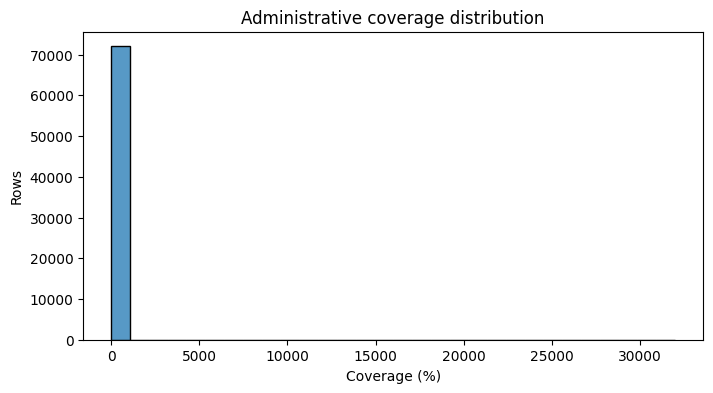

In [15]:
d=coverage_admin.coverage.dropna(); fig,ax=plt.subplots(figsize=(8,4)); sns.histplot(d,bins=30,ax=ax); ax.set(xlabel='Coverage (%)',ylabel='Rows',title='Administrative coverage distribution'); print(d.describe(percentiles=[.25,.5,.75]).round(2)); plt.show()

##### 1. Why did you pick the specific chart?

A histogram shows spread and a low-coverage tail in a bounded percentage measure.

##### 2. What is/are the insight(s) found from the chart?

The administrative coverage median is 89.56%, with 25th and 75th percentiles of 72.00% and 96.70%. However, 3,373 administrative records exceed 100%, and the maximum is 32,000%. The raw histogram is therefore distorted; verify extreme source values and rerun this chart before interpreting its shape.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Prioritize data validation and outreach after confirming targets locally.

#### Chart 2: Coverage over time


  year  median   q25   q75    n
2012.0   93.00 80.92 98.00 2066
2013.0   92.40 79.40 97.96 2135
2014.0   92.10 80.00 97.20 2295
2015.0   92.40 79.91 97.50 2422
2016.0   92.60 80.56 97.60 2582
2017.0   92.00 81.00 97.41 2861
2018.0   91.00 77.00 97.00 3948
2019.0   91.00 75.43 97.00 3996
2020.0   87.82 73.57 95.78 3862
2021.0   86.77 71.10 95.51 4085
2022.0   88.69 71.89 96.51 4260
2023.0   89.07 73.81 96.78 4346


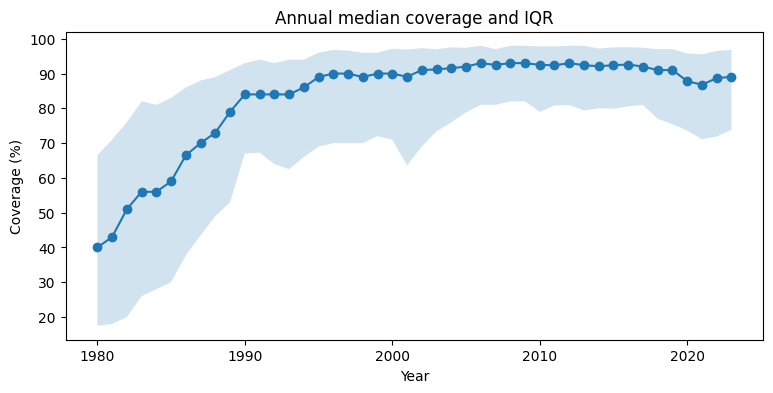

In [16]:
s=coverage_admin.groupby('year').coverage.agg(median='median',q25=lambda x:x.quantile(.25),q75=lambda x:x.quantile(.75),n='count').reset_index(); fig,ax=plt.subplots(figsize=(9,4)); ax.plot(s.year,s['median'],marker='o'); ax.fill_between(s.year,s.q25,s.q75,alpha=.2); ax.set(xlabel='Year',ylabel='Coverage (%)',title='Annual median coverage and IQR'); print(s.tail(12).round(2).to_string(index=False)); plt.show()

##### 1. Why did you pick the specific chart?

A median line and interquartile band summarize direction without letting extremes dominate.

##### 2. What is/are the insight(s) found from the chart?

The annual median declined from 93.00% in 2012 to 86.77% in 2021, then recovered to 89.07% in 2023. The 2023 median remains below 2012. Record counts also change over time, so part of the pattern may reflect reporting coverage and composition.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Investigate sustained declines after checking comparable years and reporting.

#### Chart 3: Highest 20 antigen medians in latest year

Lowest among displayed: {'IPV2': 89.28, 'JAPENC_C': 89.56, 'IPV2_FRAC': 89.79, 'PCV3': 90.78, 'ROTA1': 91.65}


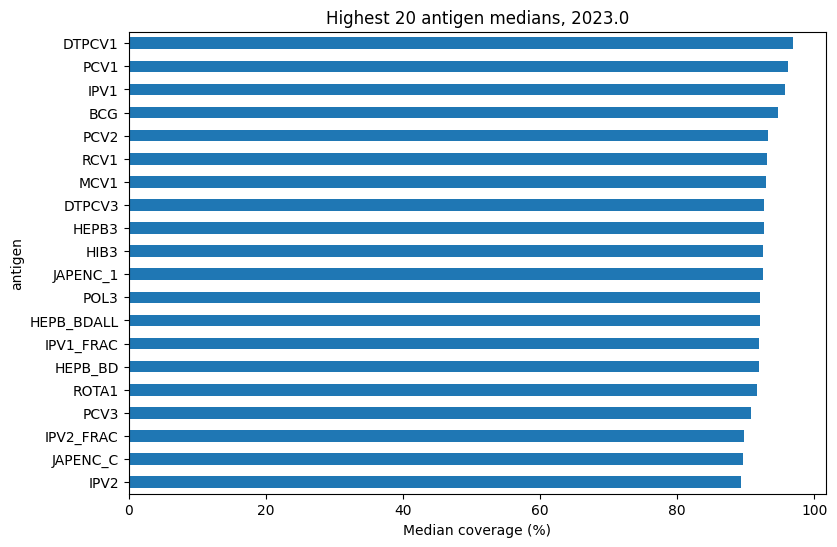

In [17]:
yr=coverage_admin.year.max(); d=coverage_admin[coverage_admin.year.eq(yr)].groupby('antigen').coverage.median().sort_values().tail(20); fig,ax=plt.subplots(figsize=(9,6)); d.plot.barh(ax=ax); ax.set(xlabel='Median coverage (%)',title=f'Highest 20 antigen medians, {yr}'); print('Lowest among displayed:',d.head().round(2).to_dict()); plt.show()

##### 1. Why did you pick the specific chart?

Ranked bars make antigen-level differences easy to compare.

##### 2. What is/are the insight(s) found from the chart?

In 2023, among the 20 antigens displayed, IPV2 has the lowest median (89.28%), followed by JAPENC_C (89.56%) and IPV2_FRAC (89.79%). This is the lowest value within the displayed top 20, not the lowest across all antigens. Change the chart title accordingly.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Focus review on antigens with low median coverage after checking definitions.

#### Chart 4: Country coverage spread


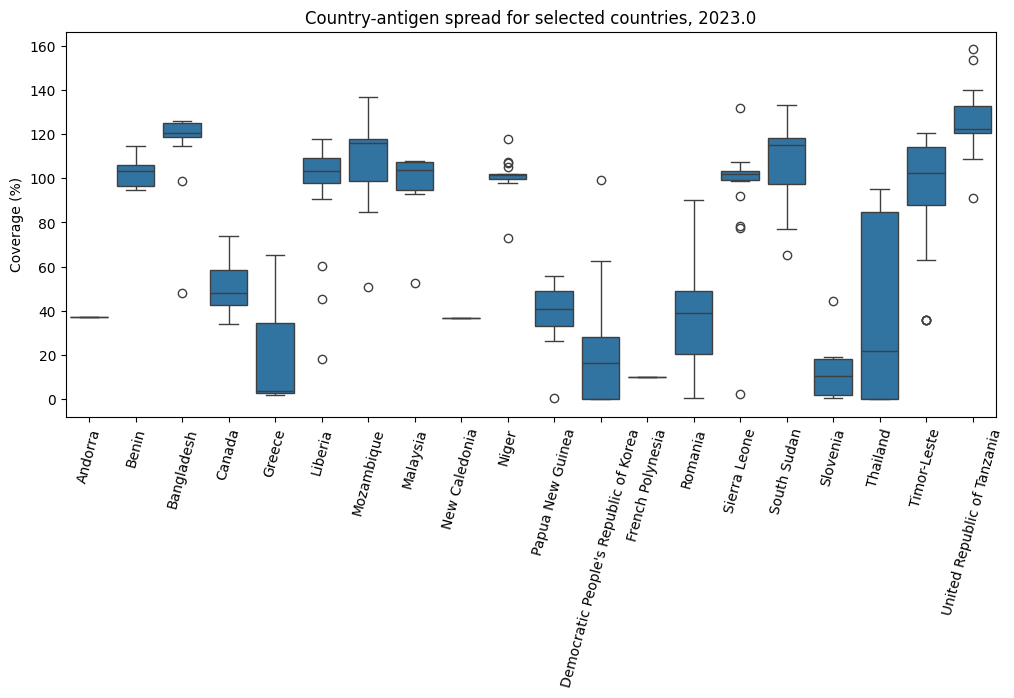

In [18]:
yr=coverage_admin.year.max(); d=coverage_admin[coverage_admin.year.eq(yr)]; med=d.groupby('name').coverage.median().sort_values(); names=list(med.head(10).index)+list(med.tail(10).index); d=d[d.name.isin(names)]; fig,ax=plt.subplots(figsize=(12,5)); sns.boxplot(data=d,x='name',y='coverage',ax=ax); ax.tick_params(axis='x',rotation=75); ax.set(title=f'Country-antigen spread for selected countries, {yr}',xlabel='',ylabel='Coverage (%)'); plt.show()

##### 1. Why did you pick the specific chart?

A box plot shows between-country spread and selected extremes.

##### 2. What is/are the insight(s) found from the chart?

The latest-year chart compares selected countries at the low and high ends of their median coverage across antigens. It shows substantial country-level variation, but the distribution combines different antigens and includes extreme values. Do not treat it as a single national coverage score; verify the observations before ranking countries.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Use low coverage for country-level follow-up, validated with local sources.

#### Chart 5: Coverage by WHO region


who_region
AFRO     80.21
AMRO     88.40
SEARO    89.24
WPRO     90.81
EMRO     91.91
EURO     93.96
Name: coverage, dtype: float64


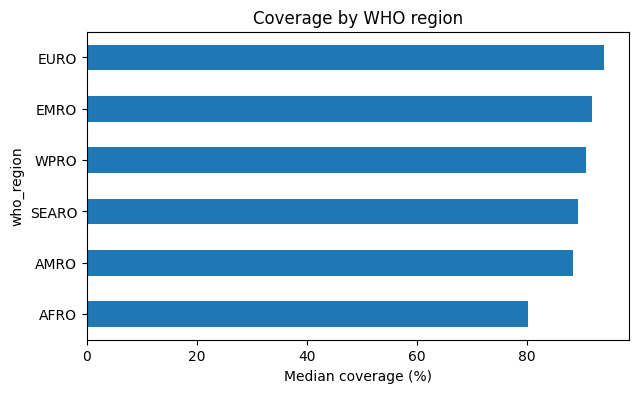

In [19]:
reg=introduction[['iso_3_code','who_region']].dropna().drop_duplicates('iso_3_code').rename(columns={'iso_3_code':'code'}); d=coverage_admin.merge(reg,on='code',how='inner',validate='many_to_one').groupby('who_region').coverage.median().sort_values(); print(d.round(2)); fig,ax=plt.subplots(figsize=(7,4)); d.plot.barh(ax=ax); ax.set(xlabel='Median coverage (%)',title='Coverage by WHO region'); plt.show()

##### 1. Why did you pick the specific chart?

Regional medians summarize broad patterns where codes map reliably to WHO regions.

##### 2. What is/are the insight(s) found from the chart?

Across the available country-year records, AFRO has the lowest regional median (80.21%) and EURO the highest (93.96%). These are pooled, unweighted medians across years, not latest-year or population-weighted estimates. Use country-level results for follow-up.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Use regional gaps to guide assistance, not as a substitute for country planning.

#### Chart 6: Reported doses versus targets


       target_number        doses  coverage
count   5.000000e+03      5000.00   5000.00
mean    7.229046e+05    565325.05     81.94
std     3.124672e+06   2138266.33     24.74
min     0.000000e+00         0.00      0.00
25%     1.783650e+04     13523.50     76.06
50%     1.224990e+05     88064.00     91.00
75%     5.630998e+05    442900.00     97.00
max     1.464426e+08  73953491.00    300.55


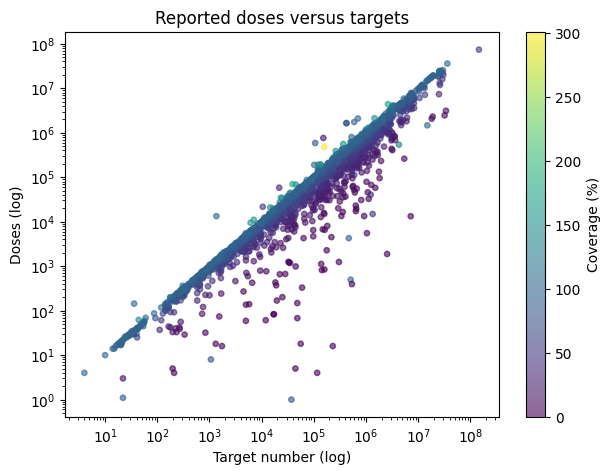

In [20]:
d=coverage_admin.dropna(subset=['target_number','doses','coverage']).sample(min(5000,len(coverage_admin)),random_state=4); fig,ax=plt.subplots(figsize=(7,5)); pts=ax.scatter(d.target_number,d.doses,c=d.coverage,cmap='viridis',alpha=.6,s=15); ax.set_xscale('log'); ax.set_yscale('log'); ax.set(xlabel='Target number (log)',ylabel='Doses (log)',title='Reported doses versus targets'); fig.colorbar(pts,label='Coverage (%)'); print(d[['target_number','doses','coverage']].describe().round(2)); plt.show()

##### 1. Why did you pick the specific chart?

A scatter checks whether dose counts and target sizes have plausible relationships.

##### 2. What is/are the insight(s) found from the chart?

In the displayed 5,000-row sample, median target is 122,499 and median doses is 88,064. Some observations have doses above target and coverage above 100%; the sample maximum coverage is 300.55%. Validate counts and denominators before interpreting the relationship.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Investigate count/percentage discrepancies and denominator quality.

#### Chart 7: Target population sizes


count    5.504000e+04
mean     3.902778e+08
std      6.488942e+10
min      0.000000e+00
25%      1.865200e+04
50%      1.355850e+05
75%      5.828300e+05
max      1.170000e+13
Name: target_number, dtype: float64


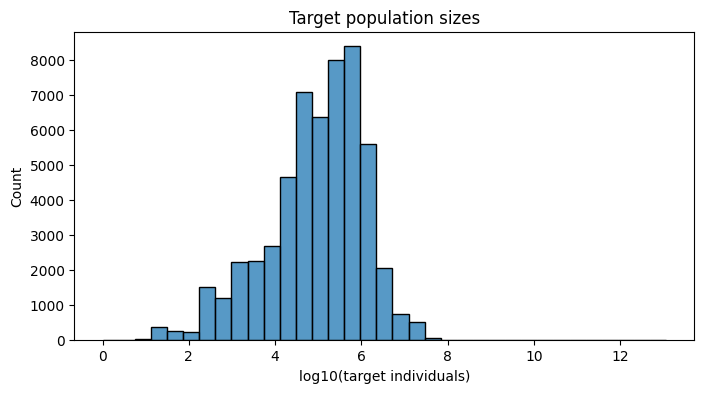

In [21]:
d=coverage_admin.target_number.dropna(); fig,ax=plt.subplots(figsize=(8,4)); sns.histplot(np.log10(d[d>0]),bins=35,ax=ax); ax.set(xlabel='log10(target individuals)',title='Target population sizes'); print(d.describe().round(1)); plt.show()

##### 1. Why did you pick the specific chart?

A log histogram shows very different target population scales.

##### 2. What is/are the insight(s) found from the chart?

The target distribution is highly skewed: its median is 135,585, while the maximum is 11.7 trillion, which is implausible for a country-level target. This extreme value distorts the chart scale. Verify it against the source and document its treatment before drawing conclusions.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Choose weighted or unweighted summaries intentionally.

#### Chart 8: Disease incidence distribution


count    61584.000
mean       109.449
std        992.277
min          0.000
50%          0.000
90%         69.200
99%       2256.538
max      69101.300
Name: incidence_rate, dtype: float64


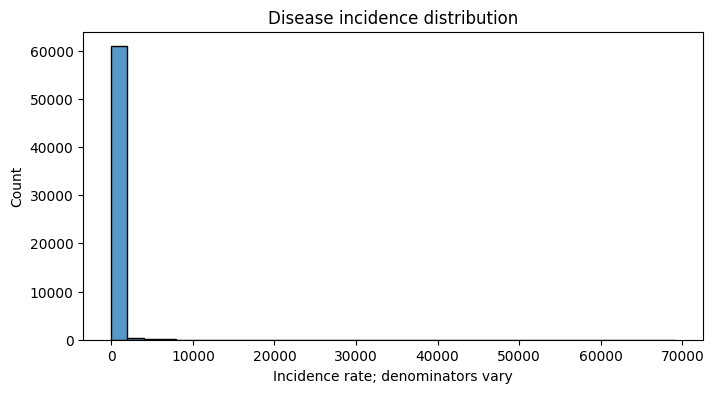

In [22]:
d=incidence.incidence_rate.dropna(); fig,ax=plt.subplots(figsize=(8,4)); sns.histplot(d,bins=35,ax=ax); ax.set(xlabel='Incidence rate; denominators vary',title='Disease incidence distribution'); print(d.describe(percentiles=[.5,.9,.99]).round(3)); plt.show()

##### 1. Why did you pick the specific chart?

A histogram illustrates the skew of disease incidence observations.

##### 2. What is/are the insight(s) found from the chart?

The pooled incidence distribution is strongly right-skewed: median 0, 90th percentile 69.2, and 99th percentile 2,256.538. The source mixes diseases with different denominators, so these pooled values describe the combined records only and cannot compare disease risk.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Review high rates with local surveillance and denominator context.

#### Chart 9: Reported cases by disease


disease
JAPENC           225494.0
NTETANUS        1503802.0
POLIO           1623271.0
DIPHTHERIA      2908251.0
TTETANUS        4888011.0
RUBELLA        16655663.0
TYPHOID        31153098.0
MUMPS          36326936.0
PERTUSSIS      53089864.0
MEASLES       144065673.0
Name: cases, dtype: float64


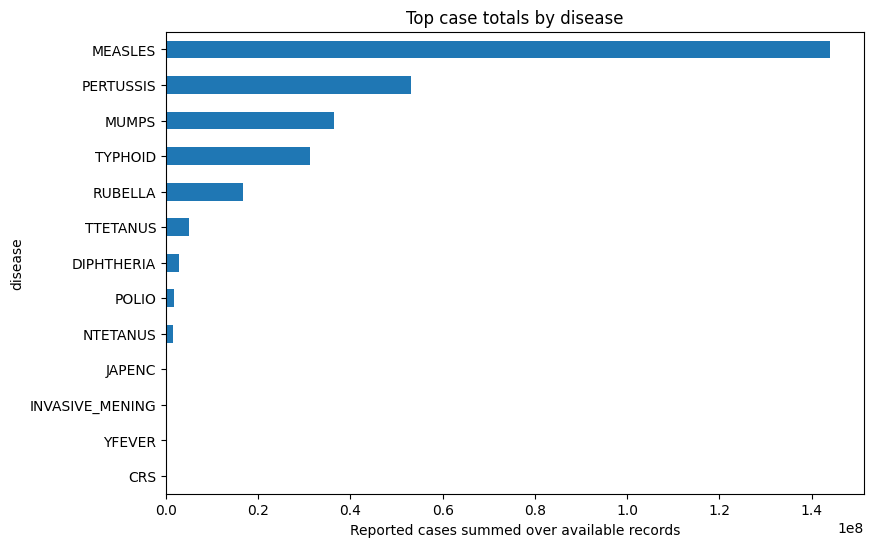

In [23]:
d=cases.groupby('disease').cases.sum().sort_values().tail(15); fig,ax=plt.subplots(figsize=(9,6)); d.plot.barh(ax=ax); ax.set(xlabel='Reported cases summed over available records',title='Top case totals by disease'); print(d.tail(10)); plt.show()

##### 1. Why did you pick the specific chart?

Ranked totals show the largest recorded case counts in the source.

##### 2. What is/are the insight(s) found from the chart?

Measles has the largest summed reported case total (144,065,673), followed by pertussis (53,089,864) and mumps (36,326,936). Totals combine countries and years and are affected by population and reporting completeness; they are not comparable measures of individual risk.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Use to focus surveillance review, then account for population and completeness.

#### Chart 10: Incidence trends by disease


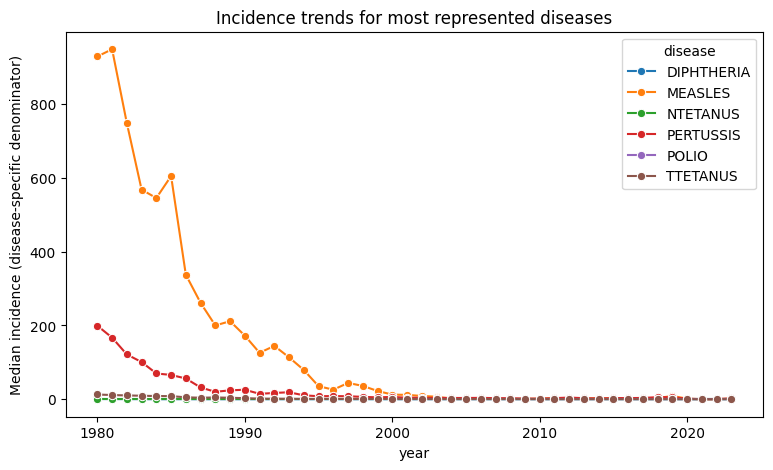

In [24]:
ds=incidence.disease.value_counts().head(6).index; d=incidence[incidence.disease.isin(ds)].groupby(['year','disease']).incidence_rate.median().reset_index(); fig,ax=plt.subplots(figsize=(9,5)); sns.lineplot(data=d,x='year',y='incidence_rate',hue='disease',marker='o',ax=ax); ax.set(title='Incidence trends for most represented diseases',ylabel='Median incidence (disease-specific denominator)'); plt.show()

##### 1. Why did you pick the specific chart?

Disease-specific trend lines show direction over time without pooling incompatible diseases.

##### 2. What is/are the insight(s) found from the chart?

The chart compares annual median incidence for the six most represented diseases. Interpret each disease line separately because denominators differ; changes can also reflect reporting and surveillance. Investigate notable increases with disease-specific context rather than pooling rates.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Flag increases for epidemiological investigation; medians are not total cases.

#### Chart 11: Vaccine introduction over time


year
2012.0    36.4
2013.0    38.4
2014.0    40.6
2015.0    44.3
2016.0    46.2
2017.0    47.6
2018.0    49.4
2019.0    48.6
2020.0    49.4
2021.0    50.5
2022.0    51.8
2023.0    53.0
Name: yes, dtype: Float64


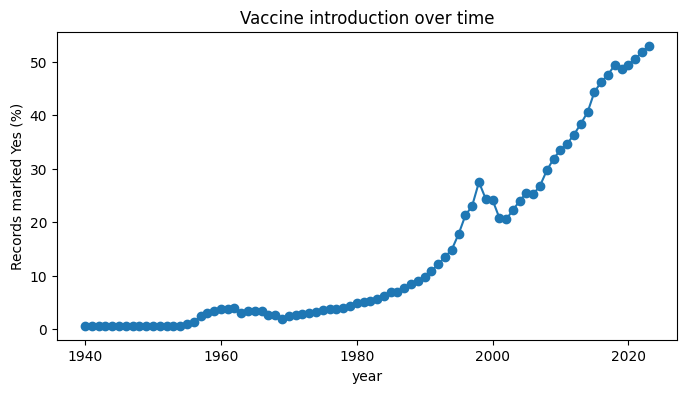

In [25]:
d=introduction.copy(); d['yes']=d.intro.astype('string').str.casefold().eq('yes'); s=d.groupby('year')['yes'].mean().mul(100); fig,ax=plt.subplots(figsize=(8,4)); s.plot(marker='o',ax=ax); ax.set(ylabel='Records marked Yes (%)',title='Vaccine introduction over time'); print(s.tail(12).round(1)); plt.show()

##### 1. Why did you pick the specific chart?

A time series tracks the share of records marked introduced.

##### 2. What is/are the insight(s) found from the chart?

The share of country-vaccine records marked Yes rose from 36.4% in 2012 to 53.0% in 2023, with a small decline from 49.4% in 2018 to 48.6% in 2019. This is reported introduction status, not vaccination coverage or the share of people vaccinated.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Identify rollout gaps for country-level follow-up.

#### Chart 12: Introduction by WHO region


who_region
AFRO     41.8
SEARO    43.7
EMRO     51.5
WPRO     54.7
EURO     59.1
AMRO     61.1
Name: yes, dtype: Float64


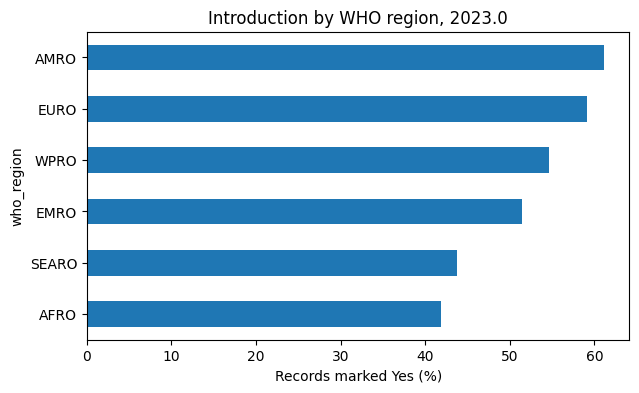

In [26]:
d=introduction.copy(); d['yes']=d.intro.astype('string').str.casefold().eq('yes'); yr=d.year.max(); s=d[d.year.eq(yr)].groupby('who_region')['yes'].mean().mul(100).sort_values(); print(s.round(1)); fig,ax=plt.subplots(figsize=(7,4)); s.plot.barh(ax=ax); ax.set(xlabel='Records marked Yes (%)',title=f'Introduction by WHO region, {yr}'); plt.show()

##### 1. Why did you pick the specific chart?

Regional bars compare reported introduction status.

##### 2. What is/are the insight(s) found from the chart?

In 2023, the share of records marked Yes ranged from 41.8% in AFRO and 43.7% in SEARO to 61.1% in AMRO. These percentages summarize introduction records, not people vaccinated, vaccine availability, or population coverage.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Guide technical support without assuming identical needs within a region.

#### Chart 13: Schedule rounds


schedulerounds
1.0    3849
2.0    1884
3.0    1139
4.0     582
5.0     419
6.0     176
7.0       3
dtype: int64


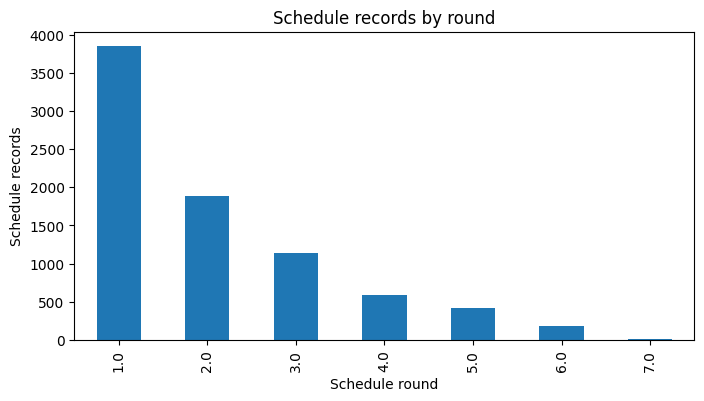

In [28]:
d=schedule.groupby('schedulerounds').size().sort_index(); fig,ax=plt.subplots(figsize=(8,4)); d.plot.bar(ax=ax); ax.set(xlabel='Schedule round',ylabel='Schedule records',title='Schedule records by round'); print(d); plt.show()

##### 1. Why did you pick the specific chart?

Schedule-round counts describe documented schedule structure.

##### 2. What is/are the insight(s) found from the chart?

Schedule entries decrease as round number increases: 3,849 records for round 1, 1,884 for round 2, 1,139 for round 3, and only three for round 7. These are documented schedule rows, not people receiving doses, so they cannot measure dose dropout.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Use schedules to plan dose-specific monitoring; dropout requires dose-level uptake data.

#### Chart 14: Schedule target populations


targetpop_description
General/routine                          4695
Risk group(s)                            1247
Adults                                    658
Pregnant women                            535
Health workers                            330
Travellers                                208
HPV for females only                      152
HPV administered to females and males     124
Catch-up children                          84
Catch-up adults                            19
Not reported                                1
Name: count, dtype: int64


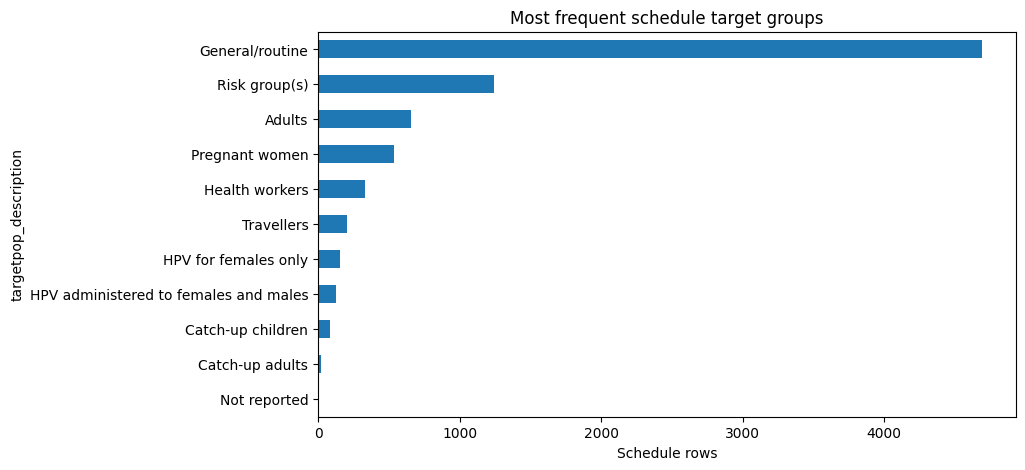

In [29]:
d=schedule.targetpop_description.fillna('Not reported').value_counts().head(12).sort_values(); fig,ax=plt.subplots(figsize=(9,5)); d.plot.barh(ax=ax); ax.set(xlabel='Schedule rows',title='Most frequent schedule target groups'); print(d.sort_values(ascending=False)); plt.show()

##### 1. Why did you pick the specific chart?

Horizontal bars compare frequency of target population descriptions.

##### 2. What is/are the insight(s) found from the chart?

General/routine is the most frequent target description (4,695 schedule rows), followed by risk groups (1,247) and adults (658). These are counts of schedule descriptions, not target population sizes or vaccination rates.

#### Chart 15: Coverage and incidence association


Matched rows 21726 Spearman rho -0.27036583342507253


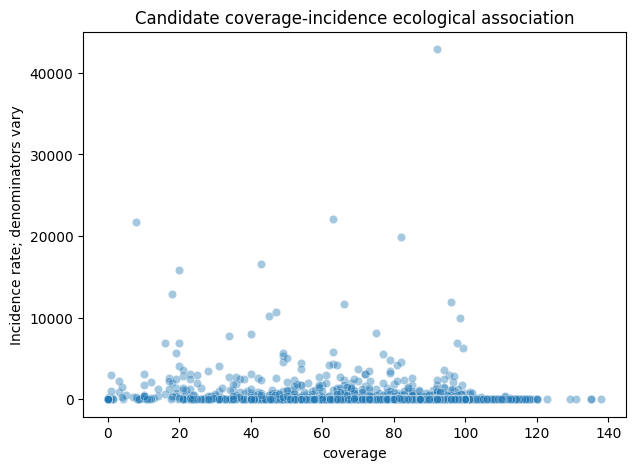

In [30]:
pairs={'MEASLES':['MEASLES','MCV1','MCV2'],'POLIO':['POL3','IPV1','IPV2'],'DIPHTHERIA':['DTP1','DTP3','DIPHCV1','DIPHCV3'],'HEPATITIS_B':['HEPB3','HEPB_BD'],'TUBERCULOSIS':['BCG'],'RUBELLA':['RUBELLA','RCV1']}; parts=[]; c=coverage_admin.copy(); c['a']=c.antigen.astype('string').str.upper()
for disease,ants in pairs.items():
 for antigen in ants:
  a=c[c.a.eq(antigen)][['code','year','coverage']]; b=incidence[incidence.disease_norm.str.contains(disease,na=False)][['code','year','incidence_rate']];
  if len(a) and len(b): parts.append(a.merge(b,on=['code','year'],how='inner'))
m=pd.concat(parts,ignore_index=True) if parts else pd.DataFrame(); rho=m[['coverage','incidence_rate']].corr(method='spearman').iloc[0,1] if len(m)>2 and m.coverage.nunique()>1 and m.incidence_rate.nunique()>1 else np.nan; print('Matched rows',len(m),'Spearman rho',rho); fig,ax=plt.subplots(figsize=(7,5)); sns.scatterplot(data=m.sample(min(5000,len(m)),random_state=2),x='coverage',y='incidence_rate',alpha=.4,ax=ax); ax.set(title='Candidate coverage-incidence ecological association',ylabel='Incidence rate; denominators vary'); plt.show()

##### 1. Why did you pick the specific chart?

A scatter displays a restricted ecological association using explicit candidate mappings.

##### 2. What is/are the insight(s) found from the chart?

The candidate country-year coverage/incidence comparison has 21,726 matched rows and Spearman rho −0.270. This is a modest negative ecological association pooled across candidate diseases and denominators; it does not show that vaccination caused lower incidence or establish vaccine effectiveness.

#### Chart 16: Coverage by WHO region and antigen


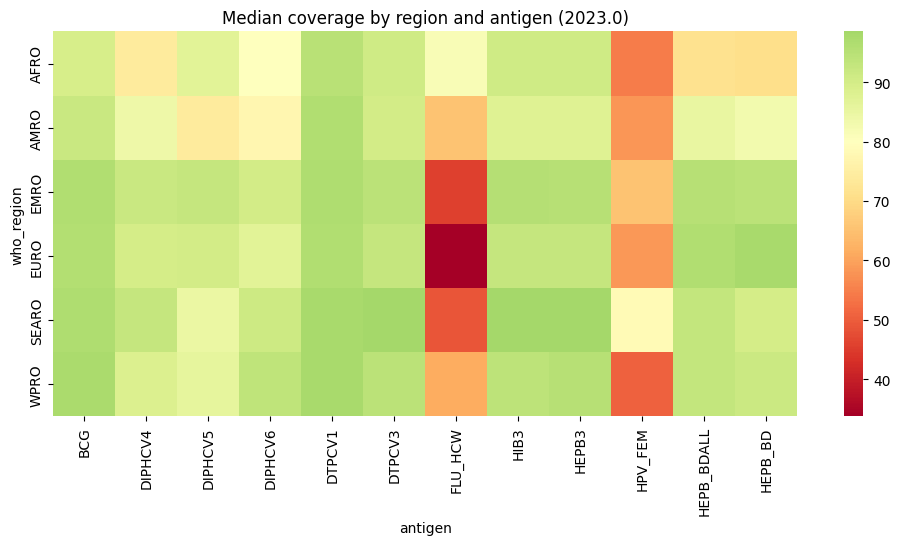

In [31]:
reg=introduction[['iso_3_code','who_region']].dropna().drop_duplicates('iso_3_code').rename(columns={'iso_3_code':'code'}); d=coverage_admin.merge(reg,on='code',how='inner',validate='many_to_one'); yr=d.year.max(); p=d[d.year.eq(yr)].pivot_table(index='who_region',columns='antigen',values='coverage',aggfunc='median'); keep=p.count().sort_values(ascending=False).head(12).index; p=p.loc[:,keep]; fig,ax=plt.subplots(figsize=(12,5)); sns.heatmap(p,cmap='RdYlGn',center=80,ax=ax); ax.set_title(f'Median coverage by region and antigen ({yr})'); plt.show()

##### Why this chart?

A heatmap shows region-antigen combinations with lower coverage.


The latest-year heatmap shows variation across region-antigen combinations. Sparse cells can make a median unstable, and extreme source values may affect color scaling. Review each low/high cell’s country records and counts before using it to prioritize resources.

##### Business impact

Drill to country-level observations before allocating support.


#### Chart 17: Reported cases by region and disease


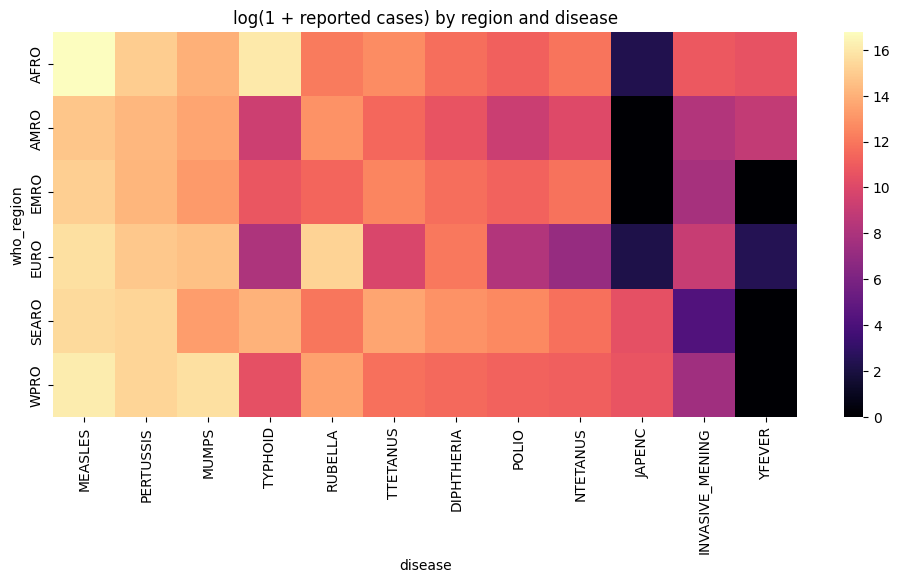

In [32]:
reg=introduction[['iso_3_code','who_region']].dropna().drop_duplicates('iso_3_code').rename(columns={'iso_3_code':'code'}); d=cases.merge(reg,on='code',how='inner',validate='many_to_one'); p=d.pivot_table(index='who_region',columns='disease',values='cases',aggfunc='sum',fill_value=0); cols=p.sum().sort_values(ascending=False).head(12).index; fig,ax=plt.subplots(figsize=(12,5)); sns.heatmap(np.log1p(p[cols]),cmap='magma',ax=ax); ax.set_title('log(1 + reported cases) by region and disease'); plt.show()

##### Why this chart?

A heatmap locates concentrations of reported cases across regions and diseases.


The heatmap shows reported case totals by region and disease; measles has high totals in several regions, including AFRO and WPRO. Totals are not population-adjusted and combine available years, so population size and surveillance completeness affect the pattern.

##### Business impact

Focus surveillance review; do not rank underlying risk without denominators.


#### Chart 18: Coverage by reporting category


coverage_category
HPV         26.00
PAB         78.00
WUENIC      88.00
ADMIN       89.56
OFFICIAL    90.05
Name: coverage, dtype: float64


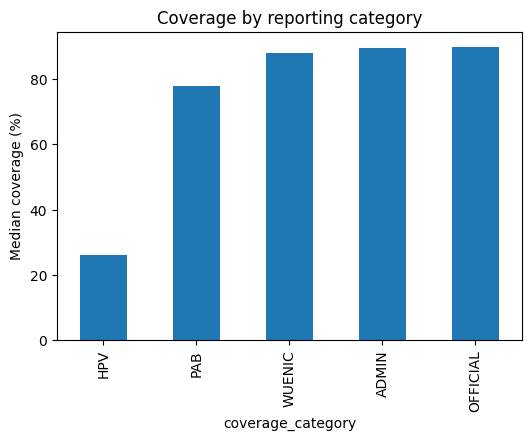

In [33]:
d=coverage.dropna(subset=['coverage']).groupby('coverage_category').coverage.median().sort_values(); print(d.round(2)); fig,ax=plt.subplots(figsize=(6,4)); d.plot.bar(ax=ax); ax.set(ylabel='Median coverage (%)',title='Coverage by reporting category'); plt.show()

##### Why this chart?

A direct comparison flags potential differences between reporting categories.


Median coverage varies by reporting category: HPV 26.00%, PAB 78.00%, WUENIC 88.00%, ADMIN 89.56%, and OFFICIAL 90.05%. The categories may represent different methods or subsets. Treat the differences as a data-quality check, not as separate population outcomes.

##### Business impact

Investigate discrepancies and select a consistent measure for tracking.


#### Chart 19: Coverage threshold attainment


All observation attainment: 33.25 %


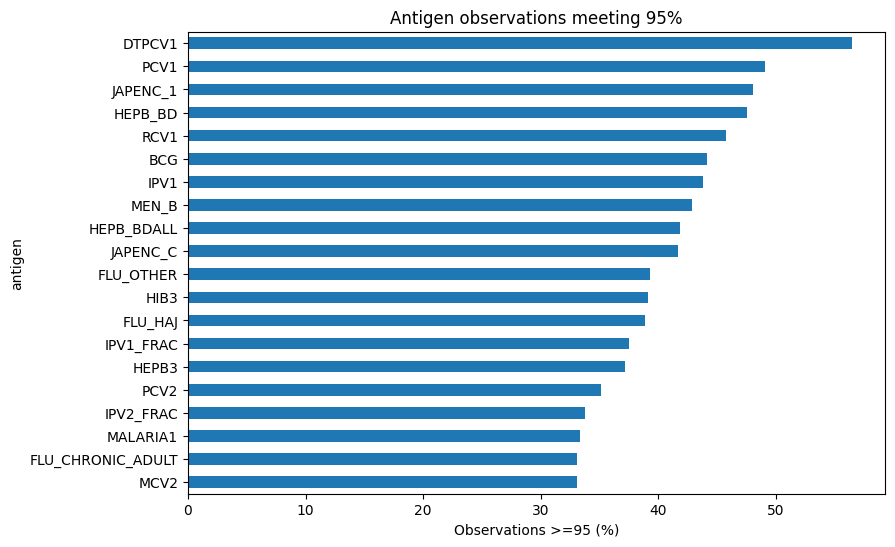

In [34]:
d=coverage_admin.copy(); d['above95']=d.coverage.ge(95); s=d.groupby('antigen').above95.mean().mul(100).sort_values().tail(20); fig,ax=plt.subplots(figsize=(9,6)); s.plot.barh(ax=ax); ax.set(xlabel='Observations >=95 (%)',title='Antigen observations meeting 95%'); print('All observation attainment:',round(d.above95.mean()*100,2),'%'); plt.show()

##### Why this chart?

The 95% benchmark is the report’s measles goal and should not be generalized to all antigens.


33.25% of all administrative coverage observations are at or above 95%. This pools antigens and years and is not population-weighted or measles-specific. Assess the 95% measles goal using country-year records for the relevant measles antigens only.

##### Business impact

Use country-level measles indicators to monitor the 95% objective.


#### Chart 20: Multivariate coverage and disease view


       coverage  incidence_rate      cases
count  19357.00         14773.0   19357.00
mean      81.36           215.5    2063.24
std       22.78          1430.4   13618.67
min        0.00             0.0       0.00
25%       74.00             0.0       0.00
50%       90.00             0.1       0.00
75%       96.02            21.5      72.00
max      856.00         56116.5  781475.00


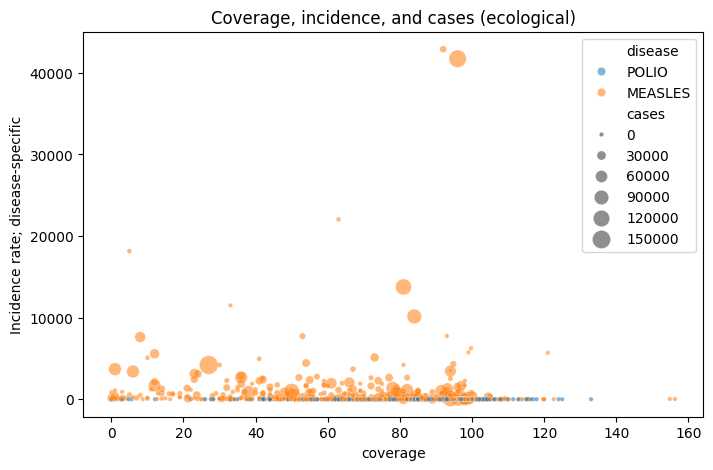

In [35]:
regi=incidence.copy(); regi['d']=regi.disease.astype('string').str.upper().str.replace(r'[^A-Z0-9]+','_',regex=True); cs=cases.copy(); cs['d']=cs.disease.astype('string').str.upper().str.replace(r'[^A-Z0-9]+','_',regex=True); parts=[]
for disease,ants in {'MEASLES':['MEASLES','MCV1','MCV2'],'POLIO':['POL3','IPV1','IPV2'],'DIPHTHERIA':['DTP1','DTP3','DIPHCV1','DIPHCV3']}.items():
 for antigen in ants:
  a=coverage_admin[coverage_admin.antigen.astype('string').str.upper().eq(antigen)][['code','year','coverage']]; b=regi[regi.d.str.contains(disease,na=False)][['code','year','incidence_rate','d']]; m=a.merge(b,on=['code','year']); cas=cs[cs.d.str.contains(disease,na=False)].groupby(['code','year']).cases.sum().reset_index(); m=m.merge(cas,on=['code','year'],how='left'); m['disease']=disease; parts.append(m)
mv=pd.concat(parts,ignore_index=True) if parts else pd.DataFrame(); print(mv[['coverage','incidence_rate','cases']].describe().round(2) if len(mv) else 'No matched rows'); fig,ax=plt.subplots(figsize=(8,5)); sns.scatterplot(data=mv.sample(min(3000,len(mv)),random_state=3),x='coverage',y='incidence_rate',size='cases',hue='disease',sizes=(10,180),alpha=.55,ax=ax); ax.set(title='Coverage, incidence, and cases (ecological)',ylabel='Incidence rate; disease-specific'); plt.show()

##### Why this chart?

A bubble view combines coverage, incidence, and case burden for triage, without population adjustment.


The bubble chart combines candidate coverage, incidence, and case counts, but points span different diseases, denominators, and reporting contexts. Bubble size is reported cases, not population risk. Treat high-incidence/high-coverage observations as leads for investigation, not evidence of vaccine failure.

##### Business impact

High incidence despite high coverage warrants checks of timing, reporting, strain, and local context.


In [36]:
print('Coverage rows:',len(coverage_admin),'Countries:',coverage_admin.code.nunique(),'Antigens:',coverage_admin.antigen.nunique())
print('Year range:',int(coverage_admin.year.min()),'to',int(coverage_admin.year.max()))
print('Median coverage:',round(coverage_admin.coverage.median(),2),'%')
print('Share below 95%:',round((coverage_admin.coverage<95).mean()*100,2),'%')
print('Coverage missing:',round(coverage.coverage.isna().mean()*100,2),'%')


Coverage rows: 72030 Countries: 214 Antigens: 60
Year range: 1980 to 2023
Median coverage: 89.56 %
Share below 95%: 66.75 %
Coverage missing: 42.36 %


## **5. Solution to Business Objective**

Prioritize country-antigen observations with low administrative coverage after validating the denominator and the country’s latest reporting year. The overall administrative median is 89.56%, and 66.75% of available observation rows fall below 95%; these values motivate follow-up but do not measure population-weighted measles target attainment. Use the country-antigen detail rather than the pooled statistic for resource planning. Track administrative coverage consistently and investigate differences from official estimates. Pair disease outcomes with explicit antigen-disease mappings only as surveillance signals. Use introduction and schedule records to identify program monitoring gaps. Collect individual and subannual data before attempting demographic or seasonal comparisons. Do not interpret ecological correlations as causal effects.


Prioritize country-antigen-year observations with low reported coverage for local verification and follow-up. The administrative series has a median of 89.56%, and 66.75% of nonmissing observation rows are below 95%; these are unweighted, all-antigen screening statistics, not population-weighted measles attainment. Review coverage alongside target and dose counts, introduction status, schedules, and disease outcomes, checking source definitions first. Use results to guide further investigation and resource planning, not as causal estimates of vaccine effectiveness. Before acting on the charts, verify the extreme source values noted in the data-quality review and rerun affected analyses.

The source data support a reproducible country-year analysis of coverage, vaccine introduction and schedules, reported cases, and incidence. The primary administrative series spans 1980–2023 and has a median reported coverage of 89.56%; 66.75% of nonmissing observation rows are below 95%. Those row-level statistics are useful for screening but are not population-weighted coverage or proof of measles-target failure. Nulls and parallel reporting categories are preserved, and joins require care because source grains differ. Interpretation is limited by aggregation, reporting differences, denominator variation, and absent demographic/monthly fields. The accompanying SQLite database and cleaned exports provide a foundation for Power BI. Add contributor details, execute and review the notebook, and include a native `.pbix` dashboard if required.


The five country-level datasets support analysis of vaccination coverage, vaccine introduction and schedules, reported cases, and incidence. Administrative coverage spans 1980–2023 for 214 countries and 60 antigens; its median is 89.56%, and 66.75% of nonmissing rows are below 95%. These are record-level screening statistics, not population-weighted or measles-only estimates. The source also contains implausible coverage and target values that require verification and transparent treatment before final interpretation. Disease comparisons are limited by denominator differences, reporting completeness, aggregation, and missing demographic/monthly data. Results should guide validation and investigation rather than be interpreted as evidence of causal effectiveness.

### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***